# Daily Casino Activity: Exploratory Data Analysis (EDA) and Machine Learning Integration

### Problem statement:
I am given three obfuscated tables describing roughly the last 7 days of activity. I needto perform EDA on this dataset by exploring it, build game-similarity and casino-cohort views, produce game recommendations for casinos, and train a model that predicts how many players a game will attract at a given casino. You will close with a set of production and business-judgement questions.



### Section 1: Understanding the Dataset

In [2]:
!pip install "snowflake-connector-python[pandas]"
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.2/89.2 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 106.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 97.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 11.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 107.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 117.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 97.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import snowflake.connector
from snowflake.connector.pandas_tools import write_pandas
import getpass
import joblib
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity


# Snowflake Credentials

In [4]:
# Securely prompt for your Snowflake password
print("Please enter your Snowflake password:")
sf_password = getpass.getpass()

# 1. Establish the Snowflake Connection
conn = snowflake.connector.connect(
    user='phikhonamthembu',
    password=sf_password,
    account='CPARMEO-XQ80160',
    role='ACCOUNTADMIN',
    warehouse='COMPUTE_WH',
    database='CASINO_GAMES_DB',
    schema='GOLD'
)
print('Successfully connected')

Please enter your Snowflake password:
··········
Successfully connected


#### 1.1	Load Data: Import the dataset into your working environment using appropriate methods or libraries.

In [5]:
query_activity = "SELECT * FROM GL_ACTIVITY"# load ACTIVITY FACT
query_games = "SELECT * FROM GL_GAME" #load GAME DIMENSION

In [6]:
print("Downloading data...")
df = pd.read_sql(query_activity, conn)
df_games = pd.read_sql(query_games, conn)

/tmp/ipykernel_726/1710292595.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query_activity, conn)
/tmp/ipykernel_726/1710292595.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_games = pd.read_sql(query_games, conn)


#### 1.2	Checking Data Shape: Determine the shape of your dataset, including the number of rows and columns.

In [7]:
df.shape # Checking the shape of the dataset

#We can see that this ca price dataset has 15 411 rows and 14 columns

(973831, 10)

In [8]:
df_games.shape # Checking the shape of the dataset

#We can see that this ca price dataset has 12 413 rows and 1 columns

(12413, 4)

#### 1.3	View Data: Display the first and last few rows of the dataset and summarize any initial insights.

In [9]:
df.head(5) # Checking the first 5 rows of the dataset


,ACTIVITY_DATE,CASINO_ID,PLAYER_ID,GAME_ID,CURRENCY_ID,TOTAL_SPINS,GOLIVE_DATE,TOTAL_WAGER_RATED,TOTAL_PAYOUT,NET_WINS
0,2026-06-22,CASINO_156,PLAYER_2522541,GAME_3740,CUR_5,18,2025-05-04,6975.649710,1115.251764,5860.397946
1,2026-06-22,CASINO_156,PLAYER_2522541,GAME_3451,CUR_5,6,2026-06-01,3420.720627,0.000000,3420.720627
2,2026-06-22,CASINO_156,PLAYER_2522541,GAME_4703,CUR_5,32,2025-09-12,15267.749940,6614.380598,8653.369342
3,2026-06-22,CASINO_156,PLAYER_2522541,GAME_11148,CUR_5,37,2025-10-05,22159.547847,10250.085399,11909.462449
4,2026-06-22,CASINO_156,PLAYER_2522541,GAME_6783,CUR_5,30,2026-06-07,16165.511090,9842.561079,6322.950011


In [10]:
df.tail(5) #Checking the last 5 rows of the dataset.

,ACTIVITY_DATE,CASINO_ID,PLAYER_ID,GAME_ID,CURRENCY_ID,TOTAL_SPINS,GOLIVE_DATE,TOTAL_WAGER_RATED,TOTAL_PAYOUT,NET_WINS
973826,2026-06-22,CASINO_209,PLAYER_1651246,GAME_6012,CUR_16,20,2026-06-30,9289.400062,12764.584778,-3475.184716
973827,2026-06-23,CASINO_380,PLAYER_1651264,GAME_4742,CUR_5,24,2026-05-24,7789.786916,2276.416947,5513.369968
973828,2026-06-23,CASINO_380,PLAYER_1651264,GAME_3177,CUR_5,458,2026-05-07,211838.364203,98742.105778,113096.258425
973829,2026-06-23,CASINO_380,PLAYER_1651264,GAME_5402,CUR_5,222,2026-06-02,37000.405524,54174.416831,-17174.011306
973830,2026-06-23,CASINO_450,PLAYER_1651288,GAME_5517,CUR_13,46,2025-07-29,3923.884979,2304.126891,1619.758089


### Section 2: Initial Data Examination

We can see that the dataset contains features independent features like wager_rated, payout, casino identifier, who the player is, what game they played

There are also categorical features such as currency


#### 2.1	Dataset Information: Provide a concise summary of the dataset, including the number of non-null entries, and explain what this reveals.

In [11]:
df.info() # Checking the data types of each column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973831 entries, 0 to 973830
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   ACTIVITY_DATE      973831 non-null  object 
 1   CASINO_ID          973831 non-null  object 
 2   PLAYER_ID          973831 non-null  object 
 3   GAME_ID            973831 non-null  object 
 4   CURRENCY_ID        973831 non-null  object 
 5   TOTAL_SPINS        973831 non-null  int64  
 6   GOLIVE_DATE        973831 non-null  object 
 7   TOTAL_WAGER_RATED  973831 non-null  float64
 8   TOTAL_PAYOUT       973831 non-null  float64
 9   NET_WINS           973831 non-null  float64
dtypes: float64(3), int64(1), object(6)
memory usage: 74.3+ MB


Summary :
We can see there are 973 831 rows and 10 columns. since all columns have 973 831 rows populated ,
there are no empty/null values. this implies that the data is of good quality. Implying that
there are strigent data vality measures that were enforced on systems that captured this dataset,
like adding Mandatory data to all fields (Not Null) data contraints.

#### 2.2 Inspect Data Types: Check data type of each column in the dataset. If columns need any data type conversion, update the data type accordingly and describe the rationale behind the conversions.

In [12]:
df.dtypes # Chaecking the columns data types

,0
ACTIVITY_DATE,object
CASINO_ID,object
PLAYER_ID,object
GAME_ID,object
CURRENCY_ID,object
TOTAL_SPINS,int64
GOLIVE_DATE,object
TOTAL_WAGER_RATED,float64
TOTAL_PAYOUT,float64
NET_WINS,float64


#### 2.3 Summary Statistics: Generate summary statistics for the numerical columns and interpret what these statistics tell you about the data.

In [13]:
df.describe() # summary statistics for numerical features.

,TOTAL_SPINS,TOTAL_WAGER_RATED,TOTAL_PAYOUT,NET_WINS
count,973831.000000,9.738310e+05,9.738310e+05,9.738310e+05
mean,130.379568,2.472618e+05,2.361064e+05,1.115542e+04
std,306.853447,2.608770e+06,2.674836e+06,6.666127e+05
min,1.000000,0.000000e+00,0.000000e+00,-3.424808e+08
25%,15.000000,4.060897e+03,1.518363e+03,1.575422e+02
50%,43.000000,2.336126e+04,1.291466e+04,3.445785e+03
75%,125.000000,1.032595e+05,8.102772e+04,2.001375e+04
max,23069.000000,7.863290e+08,9.244122e+08,1.196532e+08


Intepretation

**Total Spins** : the mean is approximately 130 spins but we have median on 43,this seems to indicate presence of skewness, also a max value of 23k for a spin is an outlier, and since this is an online game, there might be some potential of possible a bot activity.

**Total Wager**: We see same trend with wager, that there is presence of skewness, given that the median is approximately 23.3k but the mean is about 247k, there is also a huge wager value of approximately 786M, which calls for a need to do a deep dive and see aexactly what is happening.

Total Payout : again similar trend to wager, we can see a median of approaximately 12.9k but again a huge maximum value of 924M, this will also be a red flag as it directly impacts the business with low sessions but extreme returns for a wager.

Seats : the minimum seats for the vehicle cannot be 0, this seems to indicate that there might be some data entry issues.

### Section 3: Data Cleaning

#### 3.1 Handling Missing Values: Identify missing values in the dataset and describe how you handled them, including your chosen method.

In [14]:
df.isnull().sum() # Checking for missing values, and aggregating that per fearture

,0
ACTIVITY_DATE,0
CASINO_ID,0
PLAYER_ID,0
GAME_ID,0
CURRENCY_ID,0
TOTAL_SPINS,0
GOLIVE_DATE,0
TOTAL_WAGER_RATED,0
TOTAL_PAYOUT,0
NET_WINS,0


We can clearly see from teh results that there are no missing values.

If there were missing values, would approach this in two ways.

Dropping the record: I would drop records that have missing values, but this has a disadvantage of missing important data features that the model might still for learning important features.

The other method will be imputation : this will be for example, that is calculating a statistical measure like median, and replacing the null values with it. Reason I would choose specifically median is because it is not affected by any outliers, so it becomes a perfect choice for this.

#### 3.2 Handling Duplicates: Check for duplicate rows in the dataset and describe your approach to handling any duplicates found.

In [15]:
duplicates = df.duplicated().sum() # Checking for duplicates
print(duplicates)

if duplicates > 0:
  df.drop_duplicates(inplace=True) # dropping duplicates

df = df.dropna()

0


I have noted that there are no duplicates in the dataset, however I have added a process to remove them (drop) if they exist, reason for choosing this approach is so that their presence makes the model bias towards to records that appears multiple times, which will make the modal most like to memorize resulting in high variant.

#### 3.3 Outliers removal: Check if there are any outliers and remove them using graphical/non-graphical methods.

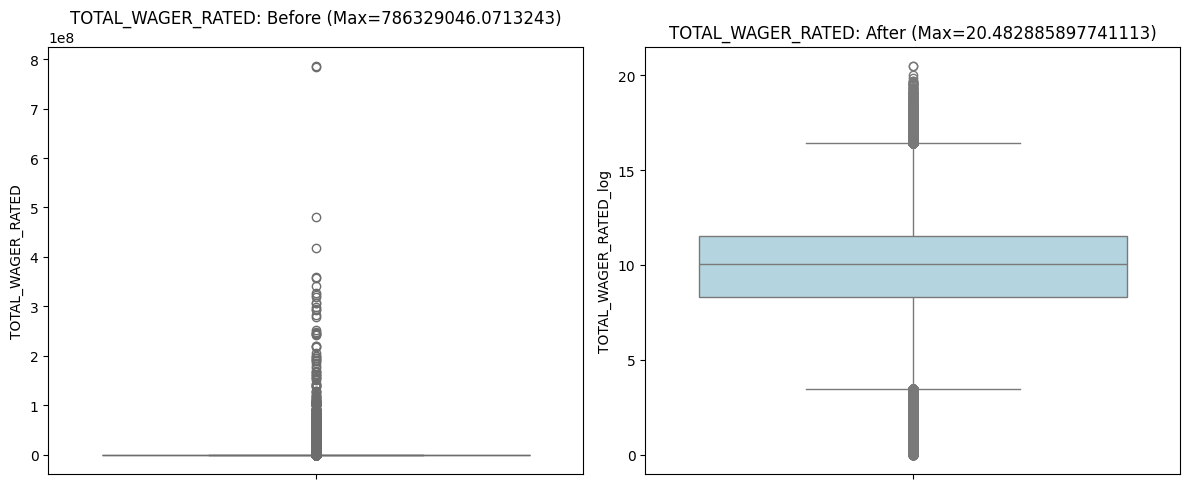

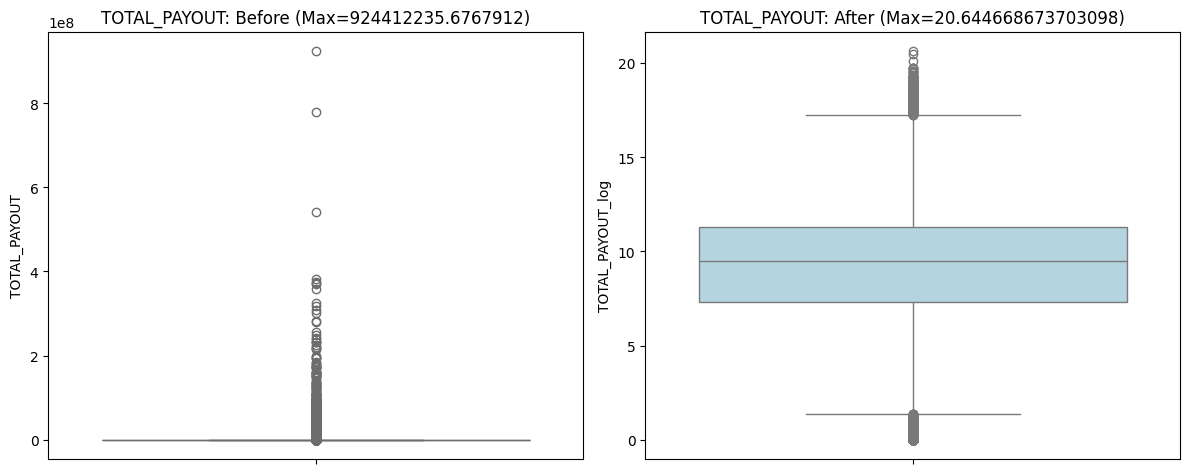

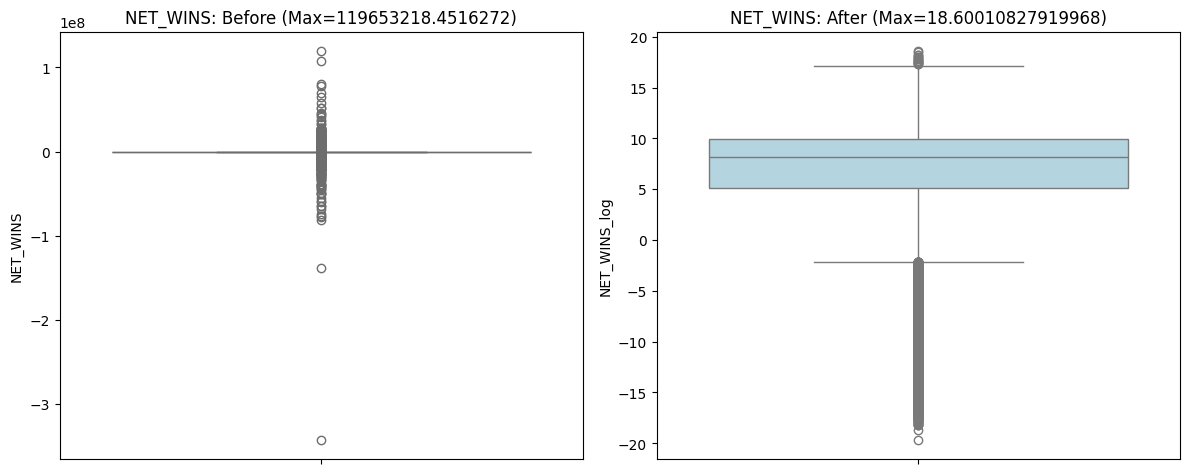

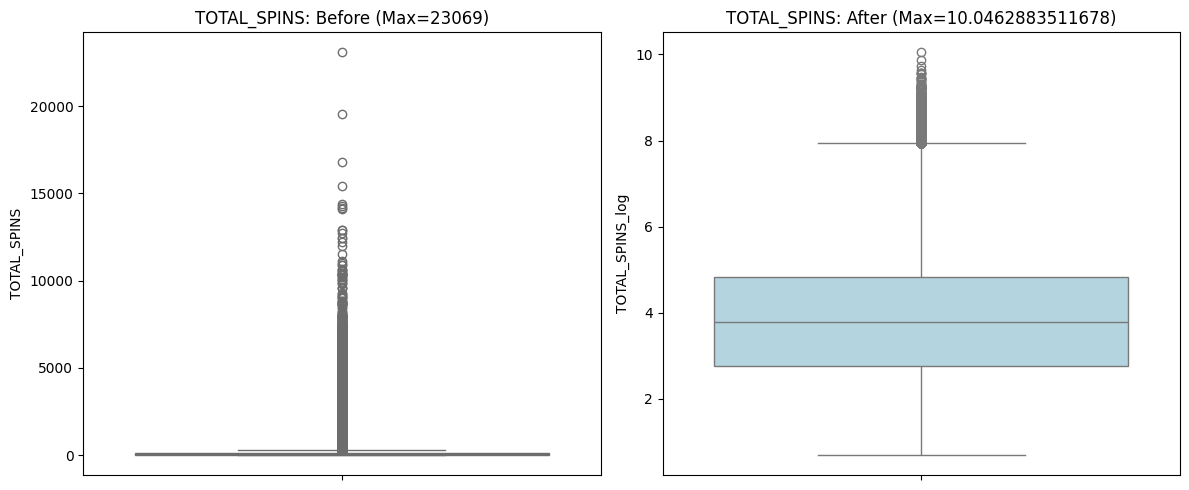

Cleaned DataFrame Shape: (973831, 14)


,ACTIVITY_DATE,CASINO_ID,PLAYER_ID,GAME_ID,CURRENCY_ID,TOTAL_SPINS,GOLIVE_DATE,TOTAL_WAGER_RATED,TOTAL_PAYOUT,NET_WINS,TOTAL_WAGER_RATED_log,TOTAL_PAYOUT_log,NET_WINS_log,TOTAL_SPINS_log
0,2026-06-22,CASINO_156,PLAYER_2522541,GAME_3740,CUR_5,18,2025-05-04,6975.649710,1115.251764,5860.397946,8.850324,7.017732,8.676143,2.944439
1,2026-06-22,CASINO_156,PLAYER_2522541,GAME_3451,CUR_5,6,2026-06-01,3420.720627,0.000000,3420.720627,8.137899,0.000000,8.137899,1.945910
2,2026-06-22,CASINO_156,PLAYER_2522541,GAME_4703,CUR_5,32,2025-09-12,15267.749940,6614.380598,8653.369342,9.633564,8.797153,9.065820,3.496508
3,2026-06-22,CASINO_156,PLAYER_2522541,GAME_11148,CUR_5,37,2025-10-05,22159.547847,10250.085399,11909.462449,10.006069,9.235139,9.385172,3.637586
4,2026-06-22,CASINO_156,PLAYER_2522541,GAME_6783,CUR_5,30,2026-06-07,16165.511090,9842.561079,6322.950011,9.690697,9.194573,8.752099,3.433987
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
973826,2026-06-22,CASINO_209,PLAYER_1651246,GAME_6012,CUR_16,20,2026-06-30,9289.400062,12764.584778,-3475.184716,9.136737,9.454508,-8.153691,3.044522
973827,2026-06-23,CASINO_380,PLAYER_1651264,GAME_4742,CUR_5,24,2026-05-24,7789.786916,2276.416947,5513.369968,8.960697,7.730797,8.615113,3.218876
973828,2026-06-23,CASINO_380,PLAYER_1651264,GAME_3177,CUR_5,458,2026-05-07,211838.364203,98742.105778,113096.258425,12.263584,11.500277,11.636003,6.129050
973829,2026-06-23,CASINO_380,PLAYER_1651264,GAME_5402,CUR_5,222,2026-06-02,37000.405524,54174.416831,-17174.011306,10.518711,10.899983,-9.751211,5.407172


In [16]:
def check_outliers_preprocessing(df, columns):
    clean_df = df.copy() # creating a clone of the df so I can cummulatively update the frame

    for col in columns:
        # Calculate quantiles on the cloned dataframe
        Q1 = clean_df[col].quantile(0.25)
        Q3 = clean_df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Setup Plotting Area
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        # Plot BEFORE cleaning (Left side)
        sns.boxplot(y=clean_df[col], ax=axes[0], color='salmon')
        axes[0].set_title(f'{col}: Before (Max={clean_df[col].max()})')

        # Calculate the median for replacement
        # col_median = clean_df[col].median() # THIS METHOD DISTORTED MY DATASET AFTER CLEANING THE OUTLIERS
        log_col_name = f'{col}_log'
        clean_df[log_col_name] = np.sign(clean_df[col]) * np.log1p(np.abs(clean_df[col]))
        col_median = clean_df[log_col_name].median()


        # Plot AFTER cleaning (Right side)
        sns.boxplot(y=clean_df[log_col_name], ax=axes[1], color='lightblue')
        axes[1].set_title(f'{col}: After (Max={clean_df[log_col_name].max()})')

        plt.tight_layout()
        plt.show() # Display the pair of plots immediately

    return clean_df



numerical_cols = ['TOTAL_WAGER_RATED', 'TOTAL_PAYOUT', 'NET_WINS', 'TOTAL_SPINS']

clean_df = check_outliers_preprocessing(df, numerical_cols)



# Print the shape to confirm no rows were dropped
print("Cleaned DataFrame Shape:", clean_df.shape)


#I have taken a strategy to show a before and after box plot so we can see the effect of the outliers in the dataset
# I have also taken a stunt of, instead of dropping the outliers, we calculate the median of each feature for identified outliers,
#and replease those values with the median, in this way, we do not loose the data but standardize it.
# this can be seen graphically on the below chats, and after removing all rows
# We have applied a logarithmic transformation of the dataset and projected that data into the whisker box plot, however, we can still detect the presence of outliers, which requires us to carefully look at the data and find more appropriate ways to handle it.


clean_df


#### 3.4 Add python comments to explain the observations.

initailly I had applied a method to replace high extreme values with median, but that has created a lot of skewness in my dataset, and I presume it is not the write method for this dataset, since I would assume lot of users would generally bet small, and only a few would bet with high amount and prolonged sessions. so I have opted for apply log transformation, also taking care of the negative net wins since log would fail on that.

### Section 4: Data Analysis

#### Univariate Analysis of numeric features: Generate histograms for numerical data and infer insights from these visualizations.

Index(['TOTAL_SPINS', 'TOTAL_WAGER_RATED', 'TOTAL_PAYOUT', 'NET_WINS',
       'TOTAL_WAGER_RATED_log', 'TOTAL_PAYOUT_log', 'NET_WINS_log',
       'TOTAL_SPINS_log'],
      dtype='object')


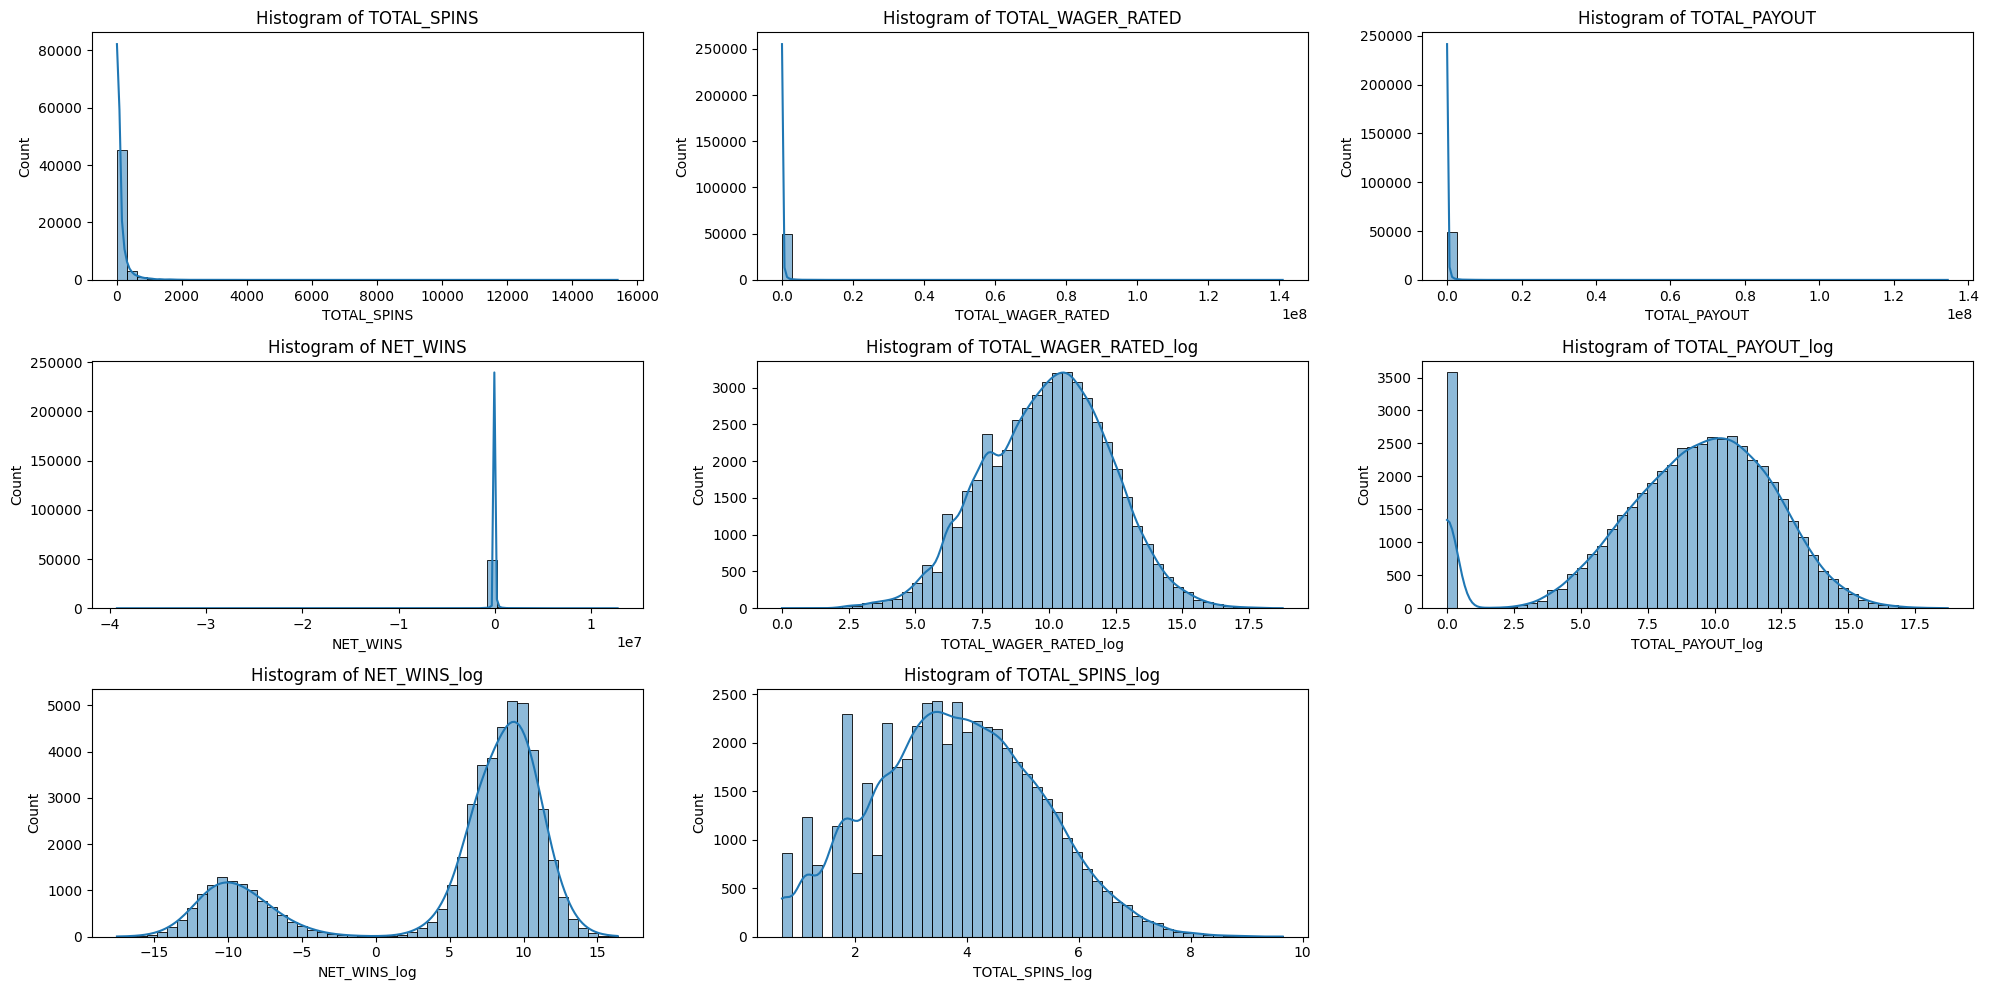

In [17]:
num_cols = clean_df.select_dtypes(include=['int64', 'float64']).columns
print(num_cols)

plt.figure(figsize=(20, 10))

# I am taking  a random sample of 50,000 rows for blazing-fast plotting, this can be increased to any value, but we are sampling the dataset directly.
sample_df = clean_df.sample(n=50000, random_state=42)

for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i + 1)
    # Plot against the sample instead of the full million-row dataframe
    sns.histplot(sample_df[col], kde=True, bins=50)
    plt.title(f'Histogram of {col}')

plt.tight_layout()
plt.show()

we can see that the log transformed charts appears to be symmetric now, still with some presence of outliers, and I am generally happy and accepting this result to continue with the rest of the assessment. the acceptance is grounded on the nature of the dataset that, generally we will have a bigger pool of users who would bet on small quanities, vs a smaller pool of users betting big.

#### 4.2 Examine the skewness in the data and apply appropriate data transformation technique.  

In [18]:
clean_df[num_cols].skew() # checking skewness before transformation, so we can measure the effect of the transformation.

,0
TOTAL_SPINS,10.584630
TOTAL_WAGER_RATED,112.383482
TOTAL_PAYOUT,121.761025
NET_WINS,-146.041412
TOTAL_WAGER_RATED_log,-0.120490
TOTAL_PAYOUT_log,-0.959406
NET_WINS_log,-1.234878
TOTAL_SPINS_log,0.103323


according to research, the general rule of thumb for interpreting skewness values is :
Between -0.5 and 0.5: The data is fairly symmetrical (approximates a normal distribution).
Between -1.0 and -0.5 OR between 0.5 and 1.0: The data is moderately skewed.
Less than -1.0 OR greater than 1.0: The data is highly skewed.

therefore we can see that all of the columns that we did not transform, based on the definition above are skewed, with total_spins, total-wager_rated, total-payout positively skewed and net-wins begatively skewed. after post log transform, all of the columns are within the acceptable range.


#### 4.3 Apply appropriate standardization method wherever applicable.

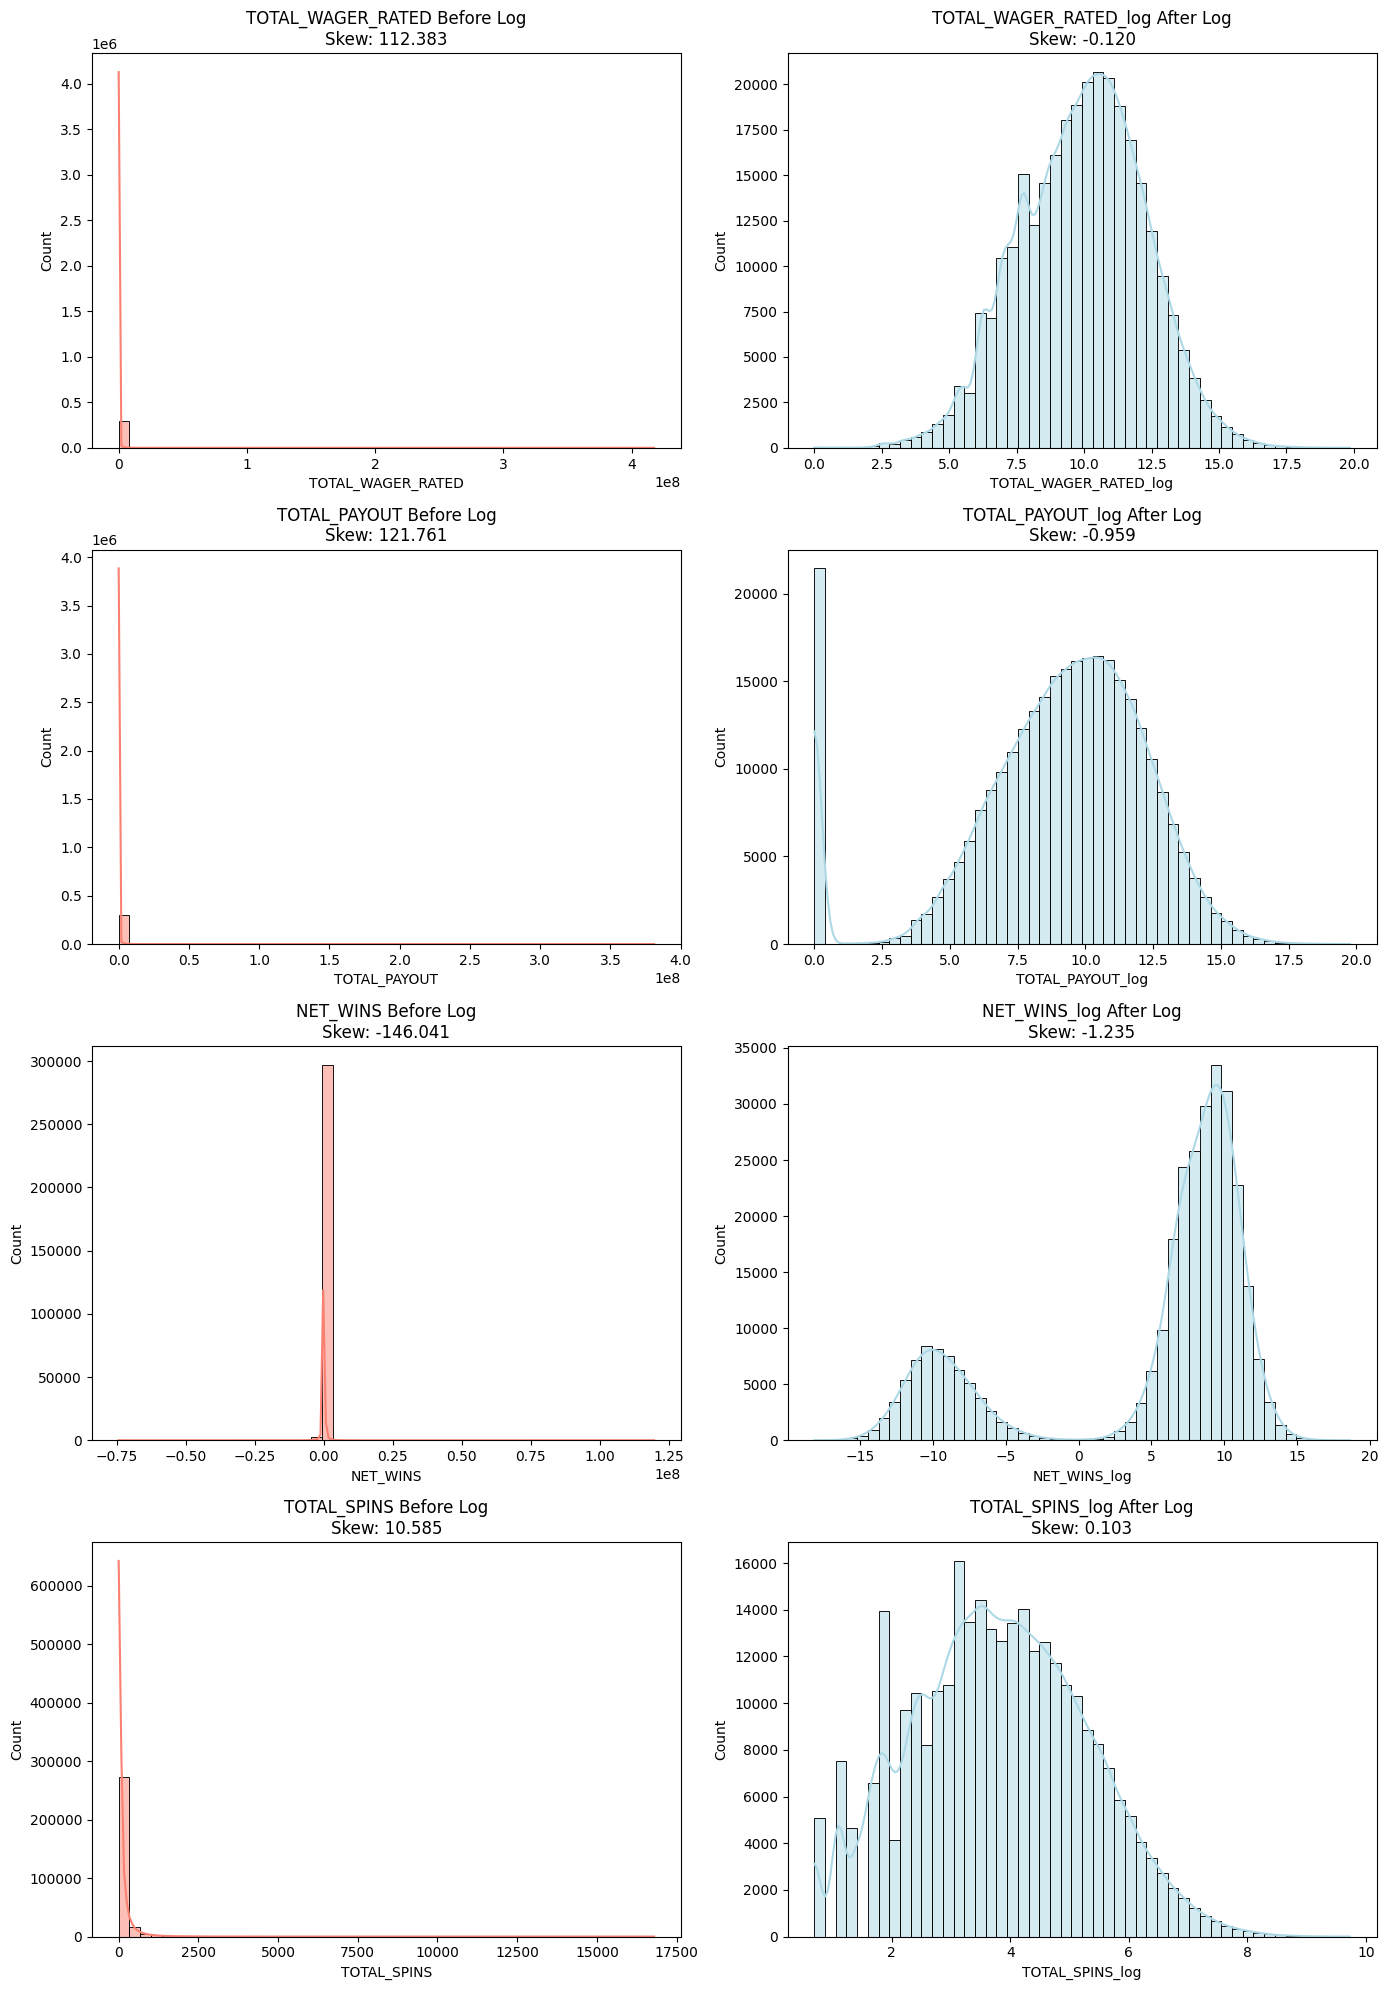

Skewness After being transformed:
TOTAL_WAGER_RATED_log   -0.120490
TOTAL_PAYOUT_log        -0.959406
NET_WINS_log            -1.234878
TOTAL_SPINS_log          0.103323
dtype: float64


In [19]:

features_to_transform = ['TOTAL_WAGER_RATED', 'TOTAL_PAYOUT', 'NET_WINS', 'TOTAL_SPINS']

fig, axes = plt.subplots(len(features_to_transform), 2, figsize=(14, 5 * len(features_to_transform)))

for i, col in enumerate(features_to_transform):
    # Take a random sample of 300,000 rows for blazing-fast plotting
    sample_raw = clean_df[col].sample(n=300000, random_state=42)

    # Plot BEFORE Log (Using the sample for speed, but calculating skew on the full column)
    sns.histplot(sample_raw, kde=True, ax=axes[i, 0], color='salmon', bins=50)
    axes[i, 0].set_title(f'{col} Before Log\nSkew: {clean_df[col].skew():.3f}')

    # Apply Signed Log Transformation to the FULL dataframe to safely handle negatives
    log_col_name = f'{col}_log'
    clean_df[log_col_name] = np.sign(clean_df[col]) * np.log1p(np.abs(clean_df[col]))

    # Sample the newly transformed column for the second plot
    sample_log = clean_df[log_col_name].sample(n=300000, random_state=42)

    # Plotting AFTER Log
    sns.histplot(sample_log, kde=True, ax=axes[i, 1], color='lightblue', bins=50)
    axes[i, 1].set_title(f'{log_col_name} After Log\nSkew: {clean_df[log_col_name].skew():.3f}')

plt.tight_layout()
plt.show()

# Displaying the new skewness values to confirm the mathematical improvement
log_columns = [f'{col}_log' for col in features_to_transform]
print("Skewness After being transformed:")
print(clean_df[log_columns].skew())




Comment : I am happy with the overall result, we can see that based on the skewness metric defination, we were able to effectively transform the features to a fairly or moderate skewness, making these feautes now fairly standardized.

Also, understanding the dataset we are working with, the clustering happening on transformed logarithm of total spins is expected, as majority of our customer base will bet on small amounts which will have relatevely fewer spins.

Therefore I am happy to accept the above numerical transformations and to proceed.

# **Feature Engineering and Enrichment**

In [20]:
clean_df = pd.merge(clean_df, df_games, on='GAME_ID', how='left')

print(clean_df.shape)
print(clean_df.columns.tolist())

clean_df.head()

(973831, 17)
['ACTIVITY_DATE', 'CASINO_ID', 'PLAYER_ID', 'GAME_ID', 'CURRENCY_ID', 'TOTAL_SPINS', 'GOLIVE_DATE', 'TOTAL_WAGER_RATED', 'TOTAL_PAYOUT', 'NET_WINS', 'TOTAL_WAGER_RATED_log', 'TOTAL_PAYOUT_log', 'NET_WINS_log', 'TOTAL_SPINS_log', 'GAME_TYPE', 'THEMES', 'MECHANICS']


,ACTIVITY_DATE,CASINO_ID,PLAYER_ID,GAME_ID,CURRENCY_ID,TOTAL_SPINS,GOLIVE_DATE,TOTAL_WAGER_RATED,TOTAL_PAYOUT,NET_WINS,TOTAL_WAGER_RATED_log,TOTAL_PAYOUT_log,NET_WINS_log,TOTAL_SPINS_log,GAME_TYPE,THEMES,MECHANICS
0,2026-06-22,CASINO_156,PLAYER_2522541,GAME_3740,CUR_5,18,2025-05-04,6975.649710,1115.251764,5860.397946,8.850324,7.017732,8.676143,2.944439,TYPE_38,"[\n ""THEME_67"",\n ""THEME_78"",\n ""THEME_86""\n]","[\n ""MECH_114"",\n ""MECH_116"",\n ""MECH_126"",..."
1,2026-06-22,CASINO_156,PLAYER_2522541,GAME_3451,CUR_5,6,2026-06-01,3420.720627,0.000000,3420.720627,8.137899,0.000000,8.137899,1.945910,TYPE_38,"[\n ""THEME_122"",\n ""THEME_60"",\n ""THEME_85""\n]","[\n ""MECH_116"",\n ""MECH_180"",\n ""MECH_188"",..."
2,2026-06-22,CASINO_156,PLAYER_2522541,GAME_4703,CUR_5,32,2025-09-12,15267.749940,6614.380598,8653.369342,9.633564,8.797153,9.065820,3.496508,TYPE_38,"[\n ""THEME_24"",\n ""THEME_78"",\n ""THEME_86""\n]","[\n ""MECH_114"",\n ""MECH_132"",\n ""MECH_168"",..."
3,2026-06-22,CASINO_156,PLAYER_2522541,GAME_11148,CUR_5,37,2025-10-05,22159.547847,10250.085399,11909.462449,10.006069,9.235139,9.385172,3.637586,TYPE_38,"[\n ""THEME_3"",\n ""THEME_8"",\n ""THEME_91""\n]","[\n ""MECH_126"",\n ""MECH_167"",\n ""MECH_168"",..."
4,2026-06-22,CASINO_156,PLAYER_2522541,GAME_6783,CUR_5,30,2026-06-07,16165.511090,9842.561079,6322.950011,9.690697,9.194573,8.752099,3.433987,TYPE_38,"[\n ""THEME_18"",\n ""THEME_3"",\n ""THEME_60""\n]","[\n ""MECH_116"",\n ""MECH_146"",\n ""MECH_168"",..."


# **Flatting THEMES & MACHANICS properties**

Flattening the dataframe and also applying one hot encoding for categorical values

In [21]:

for col in ['THEMES', 'MECHANICS']:
    clean_df[col] = clean_df[col].astype(str).str.replace(r'[\n\[\]"\s]', '', regex=True)

# multi-label so get_dummies with a separator instead of standard one-hot
themes_encoded = clean_df['THEMES'].str.get_dummies(sep=',').add_prefix('THEME_')
mechanics_encoded = clean_df['MECHANICS'].str.get_dummies(sep=',').add_prefix('MECH_')

#merging the columns back to original frame
clean_df = pd.get_dummies(clean_df, columns=['GAME_TYPE', 'CURRENCY_ID'], drop_first=True)
clean_df = pd.concat([clean_df, themes_encoded, mechanics_encoded], axis=1)
clean_df.drop(columns=['THEMES', 'MECHANICS'], inplace=True)

print(clean_df.shape)
print('CASINO_ID' in clean_df.columns)  # sanity check, don't want this getting dropped

(973831, 280)
True


In [22]:
clean_df.columns

Index(['ACTIVITY_DATE', 'CASINO_ID', 'PLAYER_ID', 'GAME_ID', 'TOTAL_SPINS',
       'GOLIVE_DATE', 'TOTAL_WAGER_RATED', 'TOTAL_PAYOUT', 'NET_WINS',
       'TOTAL_WAGER_RATED_log',
       ...
       'MECH_MECH_82', 'MECH_MECH_84', 'MECH_MECH_86', 'MECH_MECH_87',
       'MECH_MECH_88', 'MECH_MECH_90', 'MECH_MECH_91', 'MECH_MECH_92',
       'MECH_MECH_93', 'MECH_MECH_96'],
      dtype='object', length=280)

### **Part 3 - SIMILARITY**

# Reasoning for this section

We have actually already setup for responding to this section in Part 3, since we have already encoded game attributes (themes, mechanics and game_type) into clean_df dataframe. we however need to still strip off the activity data so we are able to see only game profile.

I will then use cosine similarity to pair games together.

In [23]:


# game attribute features only (one-hot themes/mechanics/type)
game_feature_cols = [col for col in clean_df.columns if col.startswith(('THEME_', 'MECH_', 'GAMETYPE_'))]

# roll up to one row per game
game_profiles = clean_df.groupby('GAME_ID')[game_feature_cols].max()

similarity_matrix = cosine_similarity(game_profiles)
similarity_df = pd.DataFrame(similarity_matrix, index=game_profiles.index, columns=game_profiles.index)


def get_best_similar_games(target_game_id, similarity_threshold=0.75):
    if target_game_id not in similarity_df.index:
        return f"Error: {target_game_id} not found in dataset."

    scores = similarity_df.loc[target_game_id].drop(target_game_id)
    best_matches = scores[scores >= similarity_threshold].sort_values(ascending=False)

    # fallback for unique games with no close matches - just grab the closest one
    if best_matches.empty:
        best_matches = scores.sort_values(ascending=False).head(1)

    result_df = pd.DataFrame({
        'Target_Game_ID': target_game_id,
        'Similar_Game_ID': best_matches.index,
        'Similarity_Score': best_matches.values
    })
    result_df['Similarity_Score'] = result_df['Similarity_Score'].round(4)

    return result_df




**Sanity Check**

In [24]:
sample_game = 'GAME_10606'
display(get_best_similar_games(sample_game)) # get similary score, with minimu threshold of 75%, randomlt chosen :)

,Target_Game_ID,Similar_Game_ID,Similarity_Score
0,GAME_10606,GAME_10614,1.0
1,GAME_10606,GAME_9562,1.0
2,GAME_10606,GAME_9571,1.0
3,GAME_10606,GAME_9579,1.0


# **Part 4 Casino Cohorts**

for this section, I will be using K means clustering and analyze the elbow method to pick up the maximum k we can use, and I will assume that the most important features for this will be:


*   Casino
*   Total players
*   How many spins
*   total wager
*   net wins
*   and also possibly the rate at which players are engaged based on activity date

these charecterstics should be able to help define and cluster casinos





In [25]:
clean_df

,ACTIVITY_DATE,CASINO_ID,PLAYER_ID,GAME_ID,TOTAL_SPINS,GOLIVE_DATE,TOTAL_WAGER_RATED,TOTAL_PAYOUT,NET_WINS,TOTAL_WAGER_RATED_log,...,MECH_MECH_82,MECH_MECH_84,MECH_MECH_86,MECH_MECH_87,MECH_MECH_88,MECH_MECH_90,MECH_MECH_91,MECH_MECH_92,MECH_MECH_93,MECH_MECH_96
0,2026-06-22,CASINO_156,PLAYER_2522541,GAME_3740,18,2025-05-04,6975.649710,1115.251764,5860.397946,8.850324,...,0,0,0,0,0,0,1,0,0,0
1,2026-06-22,CASINO_156,PLAYER_2522541,GAME_3451,6,2026-06-01,3420.720627,0.000000,3420.720627,8.137899,...,0,0,0,0,0,0,1,0,0,0
2,2026-06-22,CASINO_156,PLAYER_2522541,GAME_4703,32,2025-09-12,15267.749940,6614.380598,8653.369342,9.633564,...,0,0,0,0,0,0,1,0,0,1
3,2026-06-22,CASINO_156,PLAYER_2522541,GAME_11148,37,2025-10-05,22159.547847,10250.085399,11909.462449,10.006069,...,0,0,0,0,0,0,1,0,0,0
4,2026-06-22,CASINO_156,PLAYER_2522541,GAME_6783,30,2026-06-07,16165.511090,9842.561079,6322.950011,9.690697,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
973826,2026-06-22,CASINO_209,PLAYER_1651246,GAME_6012,20,2026-06-30,9289.400062,12764.584778,-3475.184716,9.136737,...,0,0,0,0,0,0,0,0,0,0
973827,2026-06-23,CASINO_380,PLAYER_1651264,GAME_4742,24,2026-05-24,7789.786916,2276.416947,5513.369968,8.960697,...,0,0,0,0,0,0,1,0,0,1
973828,2026-06-23,CASINO_380,PLAYER_1651264,GAME_3177,458,2026-05-07,211838.364203,98742.105778,113096.258425,12.263584,...,0,0,0,0,0,0,0,1,0,1
973829,2026-06-23,CASINO_380,PLAYER_1651264,GAME_5402,222,2026-06-02,37000.405524,54174.416831,-17174.011306,10.518711,...,0,0,0,0,0,0,0,0,0,0


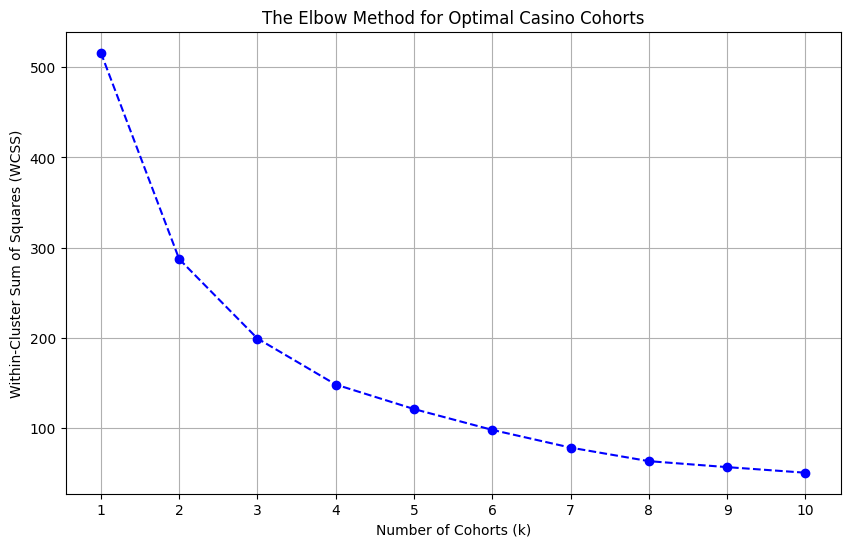

In [26]:

casino_profiles = clean_df.groupby('CASINO_ID').agg(
    TOTAL_ACTIVE_PLAYERS=('PLAYER_ID', 'nunique'),
    TOTAL_SESSIONS=('PLAYER_ID', 'count'),
    TOTAL_SPINS=('TOTAL_SPINS', 'sum'),
    TOTAL_WAGER=('TOTAL_WAGER_RATED', 'sum'),
    TOTAL_NET_WIN=('NET_WINS', 'sum')
).reset_index() # going to gold layer, extracting all casinos and grouping them by total players, sum by wins, spins and wager ratings

# applying some feature engineering and nomalization of the dataset, I have taken a concept of Average Revenue per User (ARPU)
# taken from this link : https://www.softswiss.com/knowledge-base/kpi-online-gaming/
casino_profiles['SPINS_PER_PLAYER'] = casino_profiles['TOTAL_SPINS'] / casino_profiles['TOTAL_ACTIVE_PLAYERS']
casino_profiles['WAGER_PER_PLAYER'] = casino_profiles['TOTAL_WAGER'] / casino_profiles['TOTAL_ACTIVE_PLAYERS']
casino_profiles['NET_WIN_PER_PLAYER'] = casino_profiles['TOTAL_NET_WIN'] / casino_profiles['TOTAL_ACTIVE_PLAYERS']
casino_profiles['ENGAGEMENT_RATE'] = casino_profiles['TOTAL_SESSIONS'] / casino_profiles['TOTAL_ACTIVE_PLAYERS']

features_for_clustering = [
    'SPINS_PER_PLAYER',
    'WAGER_PER_PLAYER',
    'NET_WIN_PER_PLAYER',
    'ENGAGEMENT_RATE'
]

# k-means needs scaled features since it's distance based
scaler = StandardScaler()
scaled_features = scaler.fit_transform(casino_profiles[features_for_clustering])

# elbow method to pick k
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('The Elbow Method for Optimal Casino Cohorts')
plt.xlabel('Number of Cohorts (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

Assigning K-Means clustering to cohort profiles

I have analyzed the Elbow method graph above, and have picked up that post k=4, the rate of descrease or sharpness of the curve slows down, starts to be flat, which indicates that the optimal value for k is 4.

# **Classifying Each Cohort**

In [27]:
optimal_k = 4 # assumed from the above analyses
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
casino_profiles['COHORT'] = kmeans.fit_predict(scaled_features)

# average behavior per cohort, to see what each group actually represents
cohort_summary = casino_profiles.groupby('COHORT')[features_for_clustering + ['TOTAL_ACTIVE_PLAYERS']].mean().round(2)
cohort_summary['CASINO_COUNT'] = casino_profiles.groupby('COHORT')['CASINO_ID'].count()

display(cohort_summary)

,SPINS_PER_PLAYER,WAGER_PER_PLAYER,NET_WIN_PER_PLAYER,ENGAGEMENT_RATE,TOTAL_ACTIVE_PLAYERS,CASINO_COUNT
COHORT,,,,,,
0,70.90,93805.38,-2877.66,1.32,2997.42,26
1,581.18,1573551.11,65138.47,4.83,2674.71,45
2,358.76,510779.16,11693.27,2.69,1774.02,57
3,1100.40,2928421.77,-1152779.87,5.00,5.00,1


Summary:
We can see that

**Cohort 0** is lowest engagement with 71 spins per player, this is
the cohort I would call normal.

**Cohort 1** : has 45 casinos, has 41.5mil wager per player, has a really good engagement rate and also has the highest net wins per player. therefore I will term this one High Performance

**Cohort 2**: This is the largest cohort by count with 57 casinos, however has lower active players than high performance cohort, it has positive net wins per player, it is not good but also not bad, therefore I will term it mid tier cohort.

**Cohort 3**: this for me seems out of the ordinary that we have mentioned above, and lies more as an outlier needing more attention to really do a deepdive to unpack what is happening. it has only 5 active users in just 1 casino and a huge negative net wins per player


# **Part 6,7&8**

I have decided to move part 5, 7 & 8 out of the notebook and create a streamlit application, which we can use to render and demo the application in response to these questions.

The below code, performs training, and also export the models, mlflow logs and also parquet files which will be source for the app

In [28]:
target_df = clean_df.groupby(['CASINO_ID', 'GAME_ID'])['PLAYER_ID'].nunique().reset_index()
target_df.rename(columns={'PLAYER_ID': 'PLAYER_COUNT'}, inplace=True)

casino_cohorts = casino_profiles[['CASINO_ID', 'COHORT']]
model_data = pd.merge(target_df, casino_cohorts, on='CASINO_ID', how='inner')
model_data = pd.merge(model_data, game_profiles.reset_index(), on='GAME_ID', how='inner')

X = model_data.drop(columns=['CASINO_ID', 'GAME_ID', 'PLAYER_COUNT'])
y = model_data['PLAYER_COUNT']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

mlflow.set_experiment("Casino_Player_Predictor")
mlflow.sklearn.autolog()

with mlflow.start_run(run_name="RandomForest_Base_Model"):
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf_model.fit(X_train, y_train)

    predictions = rf_model.predict(X_test)
    score = r2_score(y_test, predictions)
    print(f"R^2: {score:.2f}")

# export everything the streamlit app needs
joblib.dump(rf_model, 'player_predictor_model.joblib')
joblib.dump(list(X.columns), 'model_features.joblib')

mlflow_runs_df = mlflow.search_runs(experiment_names=["Casino_Player_Predictor"])

casino_cohorts.to_parquet('casino_cohorts.parquet')
game_profiles.to_parquet('game_profiles.parquet')
clean_df.to_parquet('clean_df.parquet')
similarity_df.to_parquet('similarity_df.parquet')
mlflow_runs_df.to_csv('training_logs.csv', index=False)

2026/07/27 20:44:29 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/27 20:44:29 INFO mlflow.store.db.utils: Updating database tables
2026/07/27 20:44:31 INFO mlflow.tracking.fluent: Experiment with name 'Casino_Player_Predictor' does not exist. Creating a new experiment.
2026/07/27 20:44:34 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Hand

R^2: -0.11
